In [63]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from pathlib import Path
import glob
from ase.io import read, write
from ase.build import make_supercell
import numpy as np

In [ ]:
def process_file(filename):
    try:
        with open(filename, "r") as f:
            lines = f.readlines()[4:-1]

        theta_data, phior_data = [], []
        for line in lines:
            values = line.split()
            if len(values) >= 13:
                try:
                    t = float(values[8])
                    p = float(values[9])
                    if np.isnan(t) or np.isnan(p):
                        continue
                    theta_data.append(t)
                    phior_data.append(p)
                except ValueError:
                    continue

        if not theta_data:
            print(f"⚠ Cap dada vàlida a {filename}, saltant...")
            return

        theta_data = np.array(theta_data)
        phior_data = np.array(phior_data)

        fig, ax = plt.subplots(figsize=(6, 5))
        h = ax.hist2d(theta_data, phior_data, bins=100, cmap='Blues', alpha=0.75)
        ax.set_title("Histograma 2D")
        ax.set_xlabel(r'$\cos(\theta)$')
        ax.set_ylabel(r'$\phi$ (graus)')
        #ax.set_xlim(-1, 1)
        #ax.set_ylim(-180, 180)
        fig.colorbar(h[3], ax=ax, label='Densitat')
        plt.tight_layout()
        plt.show()

    except FileNotFoundError:
        print(f"⚠ Fitxer {filename} no trobat, saltant...")

#filenames = sorted(glob.glob("/Users/aressanuylatorre/Desktop/doc/penta/files/ang_400_*.dat"))
filenames = sorted(glob.glob("/home/aressanuy/Desktop/doc/pentaeritritol/P0/angula/ang_550_*.dat"))
if not filenames:
    print("⚠ Cap fitxer trobat amb aquest patró")
else:
    for filename in filenames:
        print(f"Processant {filename}...")
        process_file(filename)

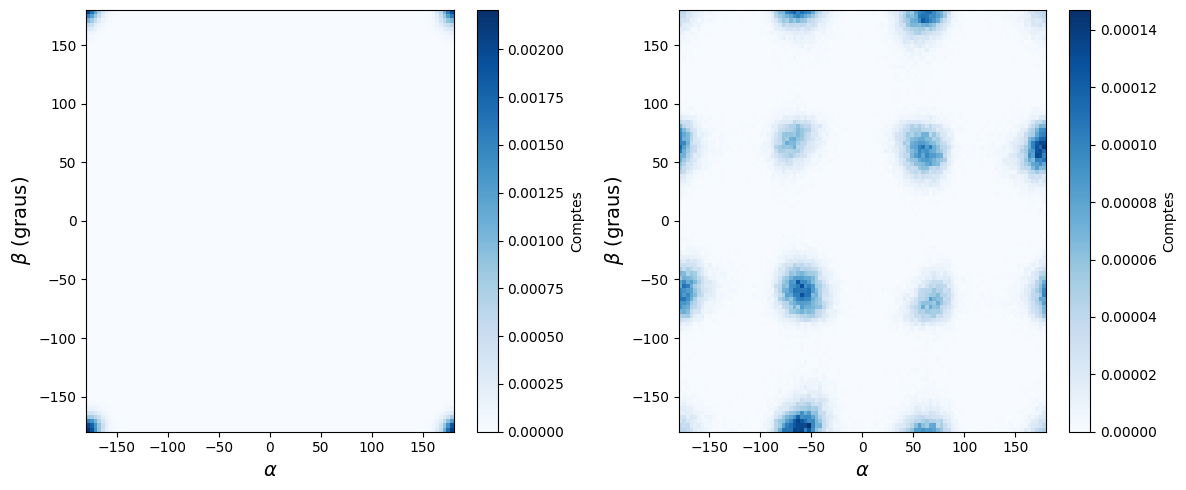

In [76]:

def read_theta_phior(filename):
    theta, phior = [], []
    with open(filename, "r") as f:
        lines = f.readlines()[4:-1]
    for line in lines:
                values = line.split()
                if len(values) >= 13:
                    try:
                        t = float(values[6])
                        p = float(values[7])
                        if np.isnan(t) or np.isnan(p):
                            continue
                        theta.append(t)
                        phior.append(p)
                    except ValueError:
                        continue
    return np.array(theta), np.array(phior)


def compare_files_2d(file_list,
                     bins=100,
                     theta_range=(-180, 180),
                     phior_range=(-180, 180)):
    #labels = ['216', '512']
    cmaps  = ['Blues', 'Blues']

    fig, axes = plt.subplots(1, len(file_list), figsize=(6 * len(file_list), 5))
    if len(file_list) == 1:
        axes = [axes]

    for i, filename in enumerate(file_list):
        theta, phior = read_theta_phior(filename)

        hist, xedges, yedges = np.histogram2d(theta, phior, bins=bins,
                                               range=[theta_range, phior_range],density=True)
        mesh = axes[i].pcolormesh(xedges, yedges, hist.T,
                                   cmap=cmaps[i % len(cmaps)])
        #axes[i].set_title(labels[i], fontsize=14)
        axes[i].set_xlabel(r'$\alpha$', fontsize=14)
        axes[i].set_ylabel(r'$\beta$ (graus)', fontsize=14)
        fig.colorbar(mesh, ax=axes[i], label='Comptes')

    plt.tight_layout()
    #plt.savefig(f"{BASE}/figures/comparativa_2d.png", dpi=150)
    plt.show()



compare_files_2d([nou_abans(1),nou_despres(1)])

# Entropia

In [64]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from pathlib import Path

mac = Path("/Users/aressanuylatorre/")

if (mac / "Desktop/doc/NPG").exists():
    BASE = str(mac / "Desktop/doc/penta/files")
    NOU  = f"{BASE}"
    print(f"BASE: MAC")
else:
    BASE = "/home/aressanuy/Desktop/doc/pentaeritritol"
    NOU  = f"{BASE}/filesang/"
    print(f"BASE: UPC")

# ==================================================
# PARELLES (T_abans, T_despres, P)
# ==================================================
parelles = {
    1:    (475, 480),
    1000: (485, 490),
    2000: (495, 500),
    3000: (510, 515),
    4000: (515, 520),
    5000: (525, 530),
}

def nou_abans(P):
    t_abans, _ = parelles[P]
    return f"{NOU}/ang_ori_{t_abans}_{P}.dat"
def nou_despres(P):
    _, t_despres = parelles[P]
    return f"{NOU}/ang_ori_{t_despres}_{P}.dat"

BASE: UPC


In [65]:
# =========================
# CONSTANTS I CODIS
# =========================
k      = 1.380649e-23
mmol   = 0.13615       # kg/mol
nmol   = 1024
NA     = 6.02214076e23
massa  = mmol/ NA   # kg (massa molecula del sistema)


def entropy_conf(fname, bins=70):
    """Entropia conformacional via histograma 2D (theta, phi)."""
    with open(fname, "r") as f:
        lines = f.readlines()[4:-1]

    theta_data, phior_data = [], []
    for line in lines:
        values = line.split()
        if len(values) >= 13:
            try:
                t = float(values[6])
                p = float(values[7])
                if np.isnan(t) or np.isnan(p):
                    continue
                theta_data.append(t)
                phior_data.append(p)
            except ValueError:
                continue

    if not theta_data:
        print(f"⚠ Cap dada vàlida a {fname}, saltant...")
        return

    theta_data = np.array(theta_data)
    phior_data = np.array(phior_data)

    edges = np.linspace(-180, 180, bins + 1)
    hist, _, _ = np.histogram2d(theta_data, phior_data, bins=[edges, edges], density=True)

    Ap = 360 / bins
    p = hist * Ap * Ap
    S = -k * np.sum(p[p > 0] * np.log(p[p > 0])) + k * np.log(Ap * Ap)

    return S / massa, p

def entropy_ori(fname, bins=100):
    th, phi, psi = [], [], []
    with open(fname) as f:
        for _ in range(4): f.readline()
        for line in f:
            cols = line.split()
            try:
                t = float(cols[8])
                p_ = float(cols[9])
                ps = float(cols[10])
                if any(np.isnan(x) for x in (t, p_, ps)):
                    continue
                th.append(t)
                phi.append(p_)
                psi.append(ps)
            except (IndexError, ValueError):
                continue
    intervals = [
        np.linspace(-1, 1, bins + 1),      # bins+1 edges → bins intervals
        np.linspace(-180, 180, bins + 1),
        np.linspace(-180, 180, bins + 1),
    ]

    hist, edges = np.histogramdd((th, phi, psi), bins=intervals)

    # Normalitzar explícitament → p suma 1 sempre
    p = hist / hist.sum()

    # Àrea del bin per la correcció d'entropia
    dth  = edges[0][1]  - edges[0][0]
    dphi = edges[1][1]  - edges[1][0]
    dpsi = edges[2][1]  - edges[2][0]
    A = dth * dphi * dpsi

    S = -k * np.sum(p[p > 0] * np.log(p[p > 0])) + k * np.log(A)
    return S / massa, p
    
    def get_edges(a):
        if a == 8:
            return np.linspace(-1, 1, bins + 1)
        else:
            return np.linspace(-180, 180, bins + 1)

    th, phi, psi = [], [], []
    with open(fname) as f:
        for _ in range(3):
            f.readline()
        for line in f:
            if not line.strip() or line.startswith('*'):
                continue
            cols = line.split()
            try:
                th.append(float(cols[8]))
                phi.append(float(cols[9]))
                psi.append(float(cols[10]))
            except (IndexError, ValueError):
                continue

    def S_2d(x, y, a1, a2):
        e1, e2 = get_edges(a1), get_edges(a2)
        hist, _, _ = np.histogram2d(x, y, bins=[e1, e2])
        p = hist / hist.sum()
        A = (e1[1]-e1[0]) * (e2[1]-e2[0])
        return -k * np.sum(p[p > 0] * np.log(p[p > 0])) + k * np.log(A)

    def S_1d(x, a):
        e = get_edges(a)
        hist, _ = np.histogram(x, bins=e)
        p = hist / hist.sum()
        d = e[1] - e[0]
        return -k * np.sum(p[p > 0] * np.log(p[p > 0])) + k * np.log(d)

    Sthphi  = S_2d(th, phi, 8, 9)
    Sthpsi  = S_2d(th, psi, 8, 10)
    Sphipsi = S_2d(phi, psi, 9, 10)
    Sth     = S_1d(th,  8)
    Sphi    = S_1d(phi, 9)
    Spsi    = S_1d(psi, 10)

    Stot = Sthphi + Sthpsi + Sphipsi - Sth - Sphi - Spsi
    return Stot / massa , p


bins_conf=200, bins_ori=20
─────────────────────────────────────────────────────────────────────────────────────────────────────────────
 P (bar)            Sc1           Sc2           ΔSc            So1           So2           ΔSo            ΔSt
─────────────────────────────────────────────────────────────────────────────────────────────────────────────
       1       440.6857      617.9444      177.2587       541.0165      753.5593      212.5428       389.8015
    1000       465.8037      619.0091      153.2054       549.8367      752.3203      202.4836       355.6890
    2000       464.4493      620.4890      156.0397       550.3842      751.3160      200.9318       356.9714
    3000       451.3249      622.7848      171.4599       547.9175      750.5490      202.6315       374.0913
    4000       453.6820      621.1341      167.4521       548.4556      749.1667      200.7111       368.1632
    5000       459.5832      623.3797      163.7965       550.1187      748.7221      198.60

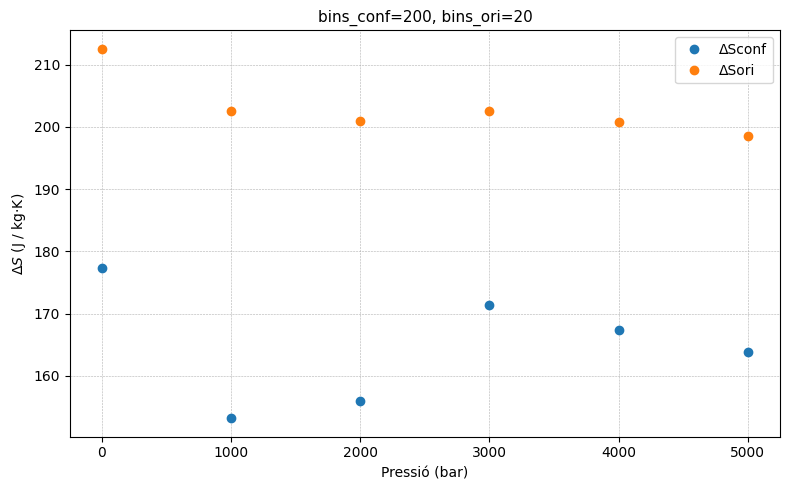

In [66]:
def analitza_entropy(parelles, nou_abans, nou_despres, bins1=200, bins2=50):
    """
    Calcula ΔSconf, ΔSori i ΔStotal per a cada pressió,
    mostra una taula formatada i fa el plot.
    """
    resultats = []

    for P in parelles:
        Sc1 = entropy_conf(nou_abans(P), bins=bins1)[0]
        Sc2 = entropy_conf(nou_despres(P), bins=bins1)[0]
        So1 = entropy_ori(nou_abans(P), bins=bins2)[0]
        So2 = entropy_ori(nou_despres(P), bins=bins2)[0]

        Sc = -Sc1 + Sc2
        So = -So1 + So2
        St = Sc + So

        resultats.append((P, Sc1, Sc2, Sc, So1, So2, So, St))

    # ── Taula ─────────────────────────────────────────────────────────────────
    col = 13
    header = (f"{'P (bar)':>8}  {'Sc1':>{col}} {'Sc2':>{col}} {'ΔSc':>{col}}"
              f"  {'So1':>{col}} {'So2':>{col}} {'ΔSo':>{col}}  {'ΔSt':>{col}}")
    sep = "─" * len(header)
    print(f"\nbins_conf={bins1}, bins_ori={bins2}")
    print(sep)
    print(header)
    print(sep)
    for P, Sc1, Sc2, Sc, So1, So2, So, St in resultats:
        print(f"{P:>8d}  {Sc1:{col}.4f} {Sc2:{col}.4f} {Sc:{col}.4f}"
              f"  {So1:{col}.4f} {So2:{col}.4f} {So:{col}.4f}  {St:{col}.4f}")
    print(sep)
    print("Unitats: J/(kg·K)")

    # ── Plot ──────────────────────────────────────────────────────────────────
    pressions = [r[0] for r in resultats]
    Sc_list   = [r[3] for r in resultats]
    So_list   = [r[6] for r in resultats]
    St_list   = [r[7] for r in resultats]

    plt.figure(figsize=(8, 5))
    plt.title(f"bins_conf={bins1}, bins_ori={bins2}", fontsize=11)
    plt.plot(pressions, Sc_list, 'o', label='ΔSconf')
    plt.plot(pressions, So_list, 'o', label='ΔSori')
    # plt.plot(pressions, St_list, 'o', label='ΔStotal')
    plt.xlabel('Pressió (bar)')
    plt.ylabel(r'$\Delta S$ (J / kg·K)')
    plt.legend()
    plt.grid(True, ls='--', lw=0.4)
    plt.tight_layout()
    plt.show()

    #return resultats

analitza_entropy(parelles, nou_abans, nou_despres, bins1=200, bins2=20)

N punts: 1228800


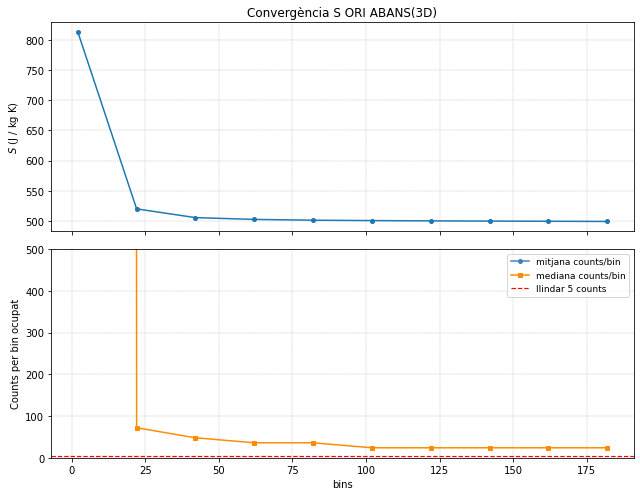

N punts: 1228800


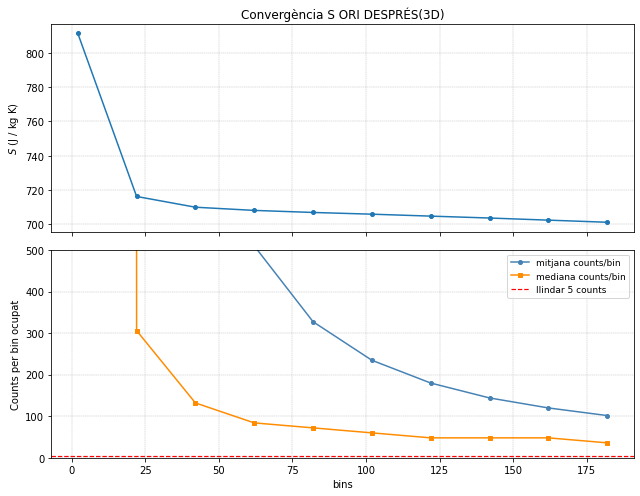

In [25]:

def count_points(fname):
    th = []
    with open(fname) as f:
        for _ in range(4): f.readline()
        for line in f:
            cols = line.split()
            try:
                th.append(float(cols[8]))
            except (IndexError, ValueError):
                continue
    print(f"N punts: {len(th)}")
    return len(th)
def diagnose_histogram_counts(fname, bins, entropy_fn=entropy_ori, label=""):
    S, p = entropy_fn(fname, bins=bins)
    
    # Reconstruir counts (p normalitzada → multipliquem per N)
    N = count_points(fname)
    counts = p * N  # counts aproximats per bin
    
    ocupats = counts[counts > 0]
    
    mean_counts  = ocupats.mean()
    median_counts = np.median(ocupats)
    below_thresh  = np.sum(ocupats < 7)
    pct_below     = 100 * below_thresh / len(ocupats)
    return mean_counts, median_counts

def convergence_plot_counts(fname, bins_list, entropy_fn=entropy_ori, 
                             threshold=7, label=""):
    N = count_points(fname)
    S_list, mean_list, median_list, pct_below_list = [], [], [], []

    for b in bins_list:
        S, p = entropy_fn(fname, bins=b)
        counts = p * N

        ocupats = counts[counts > 0]
        mean_c   = ocupats.mean()
        median_c = np.median(ocupats)
        pct_below = 100 * np.sum(ocupats < threshold) / len(ocupats)

        S_list.append(S)
        mean_list.append(mean_c)
        median_list.append(median_c)
        pct_below_list.append(pct_below)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

    ax1.plot(bins_list, S_list, '-o', ms=4)
    ax1.set_ylabel(r'$S$ (J / kg K)')
    ax1.set_title(label)
    ax1.grid(True, ls='--', lw=0.4)
    #ax1.set_ylim(0, 500)

    ax2.plot(bins_list, mean_list,   '-o', ms=4, color='steelblue',  label='mitjana counts/bin')
    ax2.plot(bins_list, median_list, '-s', ms=4, color='darkorange', label='mediana counts/bin')
    ax2.axhline(threshold, color='red', lw=1.2, ls='--', 
                label=f'llindar {threshold} counts')
    ax2.set_ylabel('Counts per bin ocupat')
    ax2.set_xlabel('bins')
    ax2.legend(fontsize=9)
    ax2.grid(True, ls='--', lw=0.4)
    ax2.set_ylim(0, 500)


    plt.tight_layout()
    plt.show()

    return (np.array(S_list), np.array(mean_list), 
            np.array(median_list), np.array(pct_below_list))

# Per conf (2D) — rang gran
S_conf, occ_conf, *_ = convergence_plot_counts(
    nou_abans(1), bins_list=np.arange(2, 200, 20),
    entropy_fn=entropy_conf,
    threshold=5,
    label="Convergència S ORI ABANS(3D)"
)

S_conf, occ_conf, *_ = convergence_plot_counts(
    nou_despres(1), bins_list=np.arange(2, 200, 20),
    entropy_fn=entropy_conf,
    threshold=5,
    label="Convergència S ORI DESPRÉS(3D)"
)

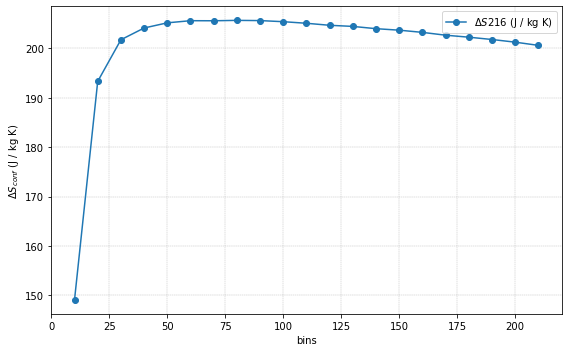

(699.4259067770332, 498.8084491147074)

In [27]:

def compare_entropy_by_bins(bins_list,
                             file_216_a, file_216_b,
                             entropy_fn=entropy_ori,
                             ylabel=r'$\Delta S$ (J / kg K)'):
    S216 = []
    llS512a,llS512b = [], []
    for b in bins_list:
        S216a = entropy_fn(file_216_a, bins=b)[0]
        S216b = entropy_fn(file_216_b, bins=b)[0]   
        S216.append(S216a - S216b)

    S216 = np.array(S216)

    plt.figure(figsize=(8, 5))
    #plt.plot(bins_list, llS512a, '-o', label='300')
    plt.plot(bins_list, S216, '-o', label=r'$\Delta S 216$ (J / kg K)')
    plt.xlabel('bins')
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True, ls='--', lw=0.4)
    plt.tight_layout()
    plt.show()

    return S216a, S216b


bins_list = np.arange(10, 220, 10)

P = 1
file_216_b = nou_abans(P)
file_216_a = nou_despres(P)


# Amb entropy_conf 
compare_entropy_by_bins(bins_list, file_216_a, file_216_b, entropy_fn=entropy_conf, ylabel=r'$\Delta S_{conf}$ (J / kg K)')

In [47]:
import numpy as np

filename = "/home/aressanuy/Desktop/doc/pentaeritritol/P2/ener_500_2000.xvg"

data = []
with open(filename, "r") as f:
    for line in f:
        if line.startswith(("#", "@")):
            continue
        values = line.split()
        if values:
            data.append([float(v) for v in values])

data = np.array(data)
labels = ["Time (ps)", "Potential (kJ/mol)", "Temperature (K)", "Pressure (bar)", "Volume (nm^3)", "Enthalpy (kJ/mol)"]

print("Mitjanes:")
for i, label in enumerate(labels):
    print(f"  {label}: {np.mean(data[:, i]):.4f}")

Mitjanes:
  Time (ps): 100.0000
  Potential (kJ/mol): -229418.3550
  Temperature (K): 499.8763
  Pressure (bar): 1985.9442
  Volume (nm^3): 189.6504
  Enthalpy (kJ/mol): -98055.7941


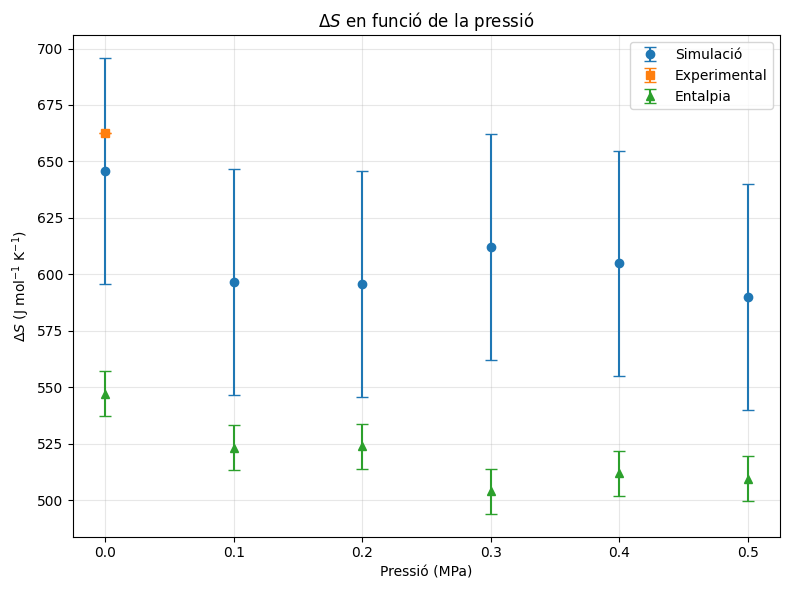

In [80]:
import numpy as np
import matplotlib.pyplot as plt

P = np.array([0.0, 0.1, 0.2, 0.3, 0.4, 0.5])
# Simulació (Ast)
S_sim = np.array([
    645.74,
    596.62,
    595.56,
    612.24,
    604.79,
    590.04
])

# Entalpia (Ash)
S_H= np.array([
    547.11,
    523.27,
    523.90,
    503.88,
    511.95,
    509.43
])

# Experimental
S_exp = np.array([
    662.50,
    np.nan,
    np.nan,
    np.nan,
    np.nan,
    np.nan
])



err_exp = 0.15 * S_exp
err_H = np.full(len(P), 10.0)
err_sim = np.full(len(P), 50.0)

plt.figure(figsize=(8,6))

plt.errorbar(
    P, S_sim, yerr=err_sim,
    fmt='o', capsize=4,
    label='Simulació'
)

plt.errorbar(
    P, S_exp, yerr=0,
    fmt='s', capsize=4,
    label='Experimental'
)


plt.errorbar(
    P, S_H, yerr=err_H,
    fmt='^', capsize=4,
    label='Entalpia'
)

plt.xlabel('Pressió (MPa)')
plt.ylabel(r'$\Delta S$ (J mol$^{-1}$ K$^{-1}$)')
plt.title(r'$\Delta S$ en funció de la pressió')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()